# Système de Recommandation - Amazon Products
## Approche simple avec Filtrage Collaboratif et Filtrage basé sur le Contenu

## 1. Découverte des Données

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Charger les données
df = pd.read_csv('Recommendation_system/Amazon_review.csv')
print("Shape du dataset:", df.shape)
print("\nPremières lignes:")
print(df.head())
print("\nInfo du dataset:")
print(df.info())
print("\nValeurs uniques dans main_category:")
print(df['main_category'].unique())
print(f"Count: {df['main_category'].value_counts()}")

Shape du dataset: (112590, 16)

Premières lignes:
  main_category                                              title  \
0    All Beauty  Howard LC0008 Leather Conditioner, 8-Ounce (4-...   
1    All Beauty  Yes to Tomatoes Detoxifying Charcoal Cleanser ...   
2    All Beauty   Eye Patch Black Adult with Tie Band (6 Per Pack)   
3    All Beauty  Tattoo Eyebrow Stickers, Waterproof Eyebrow, 4...   
4    All Beauty  Precision Plunger Bars for Cartridge Grips – 9...   

   average_rating  rating_number  \
0             4.8             10   
1             4.5              3   
2             4.4             26   
3             3.1            102   
4             4.3              7   

                                            features  \
0                                                 []   
1                                                 []   
2                                                 []   
3                                                 []   
4  ['Material: 304 Stainless Ste

In [2]:
# Analyse des données
print("Valeurs manquantes:")
print(df.isnull().sum())
print("\nStatistiques des ratings:")
print(df['average_rating'].describe())
print("\nNombre de catégories principales:")
print(df['main_category'].value_counts())

Valeurs manquantes:
main_category           0
title                  12
average_rating          0
rating_number           0
features                0
description             0
price               94886
images                  0
videos                  0
store               11344
categories              0
details                 0
parent_asin             0
bought_together    112590
subtitle           112590
author             112590
dtype: int64

Statistiques des ratings:
count    112590.000000
mean          3.883488
std           0.874384
min           1.000000
25%           3.400000
50%           4.000000
75%           4.500000
max           5.000000
Name: average_rating, dtype: float64

Nombre de catégories principales:
main_category
All Beauty        112135
Premium Beauty       455
Name: count, dtype: int64


## 2. Nettoyage et Préparation des Données

In [3]:
# Créer un dataset de travail
df_work = df[['main_category', 'title', 'average_rating', 'rating_number', 'features', 'description', 'parent_asin']].copy()

# Supprimer les lignes avec des valeurs manquantes critiques
df_work = df_work.dropna(subset=['title', 'average_rating'])

# Fonction pour convertir une colonne contenant des listes en string
def convert_list_to_string(x):
    """Convertit une liste ou string en string lisible"""
    if isinstance(x, list):
        return ' '.join(str(item).strip() for item in x if item)
    elif isinstance(x, str):
        return x.strip()
    else:
        return ''

# Convertir features et description en strings
df_work['features'] = df_work['features'].apply(convert_list_to_string)
df_work['description'] = df_work['description'].apply(convert_list_to_string)

# Supprimer les produits sans notes (rating_number = 0 ou NaN)
df_work['rating_number'] = pd.to_numeric(df_work['rating_number'], errors='coerce').fillna(0)
df_work = df_work[df_work['rating_number'] > 0]

# Créer un ID pour chaque produit
df_work['product_id'] = range(len(df_work))

print(f"Dataset après nettoyage: {df_work.shape}")
print(f"\nAperçu:")
print(df_work.head(10))
print(f"\nExemple de features converties:")
print(df_work['features'].iloc[4][:200])

Dataset après nettoyage: (112578, 8)

Aperçu:
  main_category                                              title  \
0    All Beauty  Howard LC0008 Leather Conditioner, 8-Ounce (4-...   
1    All Beauty  Yes to Tomatoes Detoxifying Charcoal Cleanser ...   
2    All Beauty   Eye Patch Black Adult with Tie Band (6 Per Pack)   
3    All Beauty  Tattoo Eyebrow Stickers, Waterproof Eyebrow, 4...   
4    All Beauty  Precision Plunger Bars for Cartridge Grips – 9...   
5    All Beauty  Lurrose 100Pcs Full Cover Fake Toenails Artifi...   
6    All Beauty  Stain Bonnet For Baby Bonnet Silk Sleep Cap Fo...   
7    All Beauty  50 Pieces False Eyelash Packaging Box Empty Ey...   
8    All Beauty                         Gold extatic Musk EDT 90ml   
9    All Beauty  4 Pieces Satin Bonnet Adjustable Sleep Cap Dou...   

   average_rating  rating_number  \
0             4.8             10   
1             4.5              3   
2             4.4             26   
3             3.1            102   
4  

In [4]:
# Prendre un sous-ensemble TRÈS PETIT pour simplifier le traitement
# On garde les produits avec au moins 10 notes ET on limite à 200 produits max
df_filtered = df_work[df_work['rating_number'] >= 10].copy()
df_filtered = df_filtered.sample(min(200, len(df_filtered)), random_state=42)  # 200 produits max aléatoires
print(f"Après filtrage (rating_number >= 10 et max 200 produits): {df_filtered.shape}")

# Réinitialiser les IDs
df_filtered = df_filtered.reset_index(drop=True)
df_filtered['product_id'] = range(len(df_filtered))

print(f"\nDonnées finales pour l'analyse:")
print(df_filtered[['main_category', 'title', 'average_rating', 'rating_number']].head(10))
print(f"\nDistribution par catégorie:")
print(df_filtered['main_category'].value_counts())

Après filtrage (rating_number >= 10 et max 200 produits): (200, 8)

Données finales pour l'analyse:
  main_category                                              title  \
0    All Beauty  Zgood 400Pcs/4 Boxes Blue Applicator Micro Bru...   
1    All Beauty  2 Pack Detangling Brush for Natural Black Hair...   
2    All Beauty  AnFun 10 Pieces Sanding Buffing Nail Polisher ...   
3    All Beauty  Sdootbeauty Airless Pump Bottle, Refillable Ai...   
4    All Beauty  16 Sheets Fake Temporary Tattoo Sticker for Adult   
5    All Beauty  Barber Hair Cutting Cape for Men Women, Made w...   
6    All Beauty  Pawotence Invisible Band False Eyelashes 2 Cat...   
7    All Beauty  Synthetic Hair Wigs Body Wave Wigs for Women N...   
8    All Beauty  Ogx Coconut Curls Decadent Creamy Mousse 7.9 O...   
9    All Beauty  ENVII – The Beauty Brand 300PK Black Disposabl...   

   average_rating  rating_number  
0             4.1             10  
1             4.1             40  
2             4.0       

## 3. Préparation des Données pour les Algorithmes

In [5]:
# Créer une matrice utilisateur-produit avec des utilisateurs virtuels FINS
# Au lieu de 1 utilisateur par catégorie, on crée plusieurs utilisateurs par catégorie
# basés sur les tranches de ratings (très bon, bon, moyen, etc.)

# Définir les tranches de ratings pour créer les utilisateurs virtuels
rating_ranges = [
    (4.5, 5.0, "Très satisfait"),
    (4.0, 4.5, "Satisfait"),
    (3.5, 4.0, "Moyennement satisfait"),
    (3.0, 3.5, "Peu satisfait"),
    (1.0, 3.0, "Insatisfait")
]

# Créer les utilisateurs virtuels
virtual_users = []
user_descriptions = []

for category in df_filtered['main_category'].unique():
    for min_rating, max_rating, description in rating_ranges:
        virtual_users.append(f"{category}_{description}")
        user_descriptions.append({
            'category': category,
            'rating_range': (min_rating, max_rating),
            'description': description
        })

n_virtual_users = len(virtual_users)
print(f"Nombre d'utilisateurs virtuels créés: {n_virtual_users}")
print(f"Utilisateurs virtuels: {virtual_users}\n")

# Créer la matrice utilisateur-produit FINE
user_product_matrix = pd.DataFrame(0.0, 
                                   index=range(n_virtual_users), 
                                   columns=range(len(df_filtered)))

# Remplir la matrice
for idx, row in df_filtered.iterrows():
    for user_idx, (category, (min_r, max_r), desc) in enumerate([(u['category'], u['rating_range'], u['description']) 
                                                                     for u in user_descriptions]):
        # Un utilisateur virtuel "aime" un produit si:
        # 1. Le produit est de sa catégorie ET son rating est dans sa tranche
        # 2. OU le produit est d'une autre catégorie mais avec un bon rating (pour permettre les recommandations croisées)
        
        if row['main_category'] == category and min_r <= row['average_rating'] <= max_r:
            # Produit de sa catégorie et dans sa tranche de ratings
            user_product_matrix.iloc[user_idx, idx] = row['average_rating']
        elif row['main_category'] != category and row['average_rating'] >= 4.0:
            # Produits d'autres catégories mais très bien notés (4.0+) pour les recommandations croisées
            user_product_matrix.iloc[user_idx, idx] = row['average_rating'] * 0.7  # Poids légèrement réduit

print(f"Matrice utilisateur-produit FINE: {user_product_matrix.shape}")
print(f"\nNombre de ratings non-zéro par utilisateur:")
print(user_product_matrix.apply(lambda x: (x > 0).sum(), axis=1))
print(f"\nPremiers utilisateurs et leurs ratings (premiers 5 produits):")
for i in range(min(3, n_virtual_users)):
    print(f"{virtual_users[i]}: {user_product_matrix.iloc[i, :5].values}")

Nombre d'utilisateurs virtuels créés: 10
Utilisateurs virtuels: ['All Beauty_Très satisfait', 'All Beauty_Satisfait', 'All Beauty_Moyennement satisfait', 'All Beauty_Peu satisfait', 'All Beauty_Insatisfait', 'Premium Beauty_Très satisfait', 'Premium Beauty_Satisfait', 'Premium Beauty_Moyennement satisfait', 'Premium Beauty_Peu satisfait', 'Premium Beauty_Insatisfait']

Matrice utilisateur-produit FINE: (10, 200)

Nombre de ratings non-zéro par utilisateur:
0     36
1     92
2     69
3     34
4     13
5    121
6    121
7    121
8    120
9    120
dtype: int64

Premiers utilisateurs et leurs ratings (premiers 5 produits):
All Beauty_Très satisfait: [0.  0.  0.  4.8 0. ]
All Beauty_Satisfait: [4.1 4.1 4.  0.  4.3]
All Beauty_Moyennement satisfait: [0. 0. 4. 0. 0.]


## 4. Filtrage Collaboratif (User-Based)

In [6]:
# Approche améliorée: Filtrage collaboratif basé sur la similarité cosinus
# avec utilisateurs virtuels FINS permettant les recommandations croisées

# Calculer la similarité entre utilisateurs
user_similarity = pd.DataFrame(cosine_similarity(user_product_matrix),
                               index=range(n_virtual_users),
                               columns=range(n_virtual_users))

print("Matrice de similarité entre utilisateurs (premiers 5x5):")
print(user_similarity.iloc[:5, :5])

# Fonction pour recommander des produits par filtrage collaboratif AMÉLIORÉ
def collaborative_filtering_recommendation(user_id, n_recommendations=5):
    """
    Recommande des produits basés sur les utilisateurs similaires
    Permet les recommandations croisées grâce aux utilisateurs virtuels fins
    """
    # Obtenir les utilisateurs similaires (sauf l'utilisateur lui-même)
    similar_users = user_similarity[user_id].sort_values(ascending=False)[1:]
    
    # Produits que l'utilisateur n'a pas notés
    user_ratings = user_product_matrix.iloc[user_id]
    unrated_products = user_ratings[user_ratings == 0].index.tolist()
    
    if not unrated_products:
        return []
    
    # Calculer les scores des produits non notés
    recommendations = {}
    for product_id in unrated_products:
        score = 0
        weight_sum = 0
        for similar_user, similarity in similar_users.items():
            if similarity > 0:
                rating = user_product_matrix.iloc[similar_user, product_id]
                if rating > 0:
                    score += similarity * rating
                    weight_sum += similarity
        
        if weight_sum > 0:
            recommendations[product_id] = score / weight_sum
    
    # Trier et retourner les top N
    sorted_recommendations = sorted(recommendations.items(), key=lambda x: x[1], reverse=True)
    return sorted_recommendations[:n_recommendations]

# Tester avec différents utilisateurs virtuels
print("\n" + "="*80)
print("RECOMMANDATIONS PAR FILTRAGE COLLABORATIF AMÉLIORÉ")
print("="*80)

for user_idx in range(min(3, n_virtual_users)):  # Montrer 3 utilisateurs
    user_name = virtual_users[user_idx]
    collab_recs = collaborative_filtering_recommendation(user_idx, n_recommendations=5)
    
    print(f"\n📌 Utilisateur virtuel: {user_name}")
    print(f"   Recommandations:")
    
    if collab_recs:
        for rank, (product_id, score) in enumerate(collab_recs, 1):
            title = df_filtered.iloc[product_id]['title'][:55]
            category = df_filtered.iloc[product_id]['main_category']
            rating = df_filtered.iloc[product_id]['average_rating']
            print(f"   {rank}. [{category}] {title}... (Score: {score:.3f}, Rating: {rating})")
    else:
        print("   Aucune recommandation disponible")

Matrice de similarité entre utilisateurs (premiers 5x5):
          0         1         2         3         4
0  1.000000  0.090597  0.022326  0.036209  0.069441
1  0.090597  1.000000  0.281664  0.024971  0.047888
2  0.022326  0.281664  1.000000  0.232364  0.061001
3  0.036209  0.024971  0.232364  1.000000  0.190595
4  0.069441  0.047888  0.061001  0.190595  1.000000

RECOMMANDATIONS PAR FILTRAGE COLLABORATIF AMÉLIORÉ

📌 Utilisateur virtuel: All Beauty_Très satisfait
   Recommandations:
   1. [All Beauty] Love Sweety Women Party Big Rose Flower Hairpin Hair Cl... (Score: 3.900, Rating: 3.9)
   2. [All Beauty] 4PCS Retro Bee Hair Ties Elastic Ponytail Holders Hair ... (Score: 3.900, Rating: 3.9)
   3. [All Beauty] Driew Pump Bottles, Shampoo Bottles with Pump Shampoo D... (Score: 3.900, Rating: 3.9)
   4. [All Beauty] Yes To Grapefruit Uneven Skin Tone, Even Skin Tone Mois... (Score: 3.900, Rating: 3.9)
   5. [All Beauty] Eye Brush Set, 20 pcs Unicorn Eyeshadow Eyeliner Blendi... (Score:

## 5. Filtrage basé sur le Contenu

In [7]:
# Filtrage basé sur le contenu utilisant les titres, features et description

# Créer du contenu combiné pour chaque produit
df_filtered['content'] = df_filtered['title'].fillna('') + ' ' + \
                         df_filtered['features'].fillna('') + ' ' + \
                         df_filtered['description'].fillna('')

print(f"Exemple de contenu combiné (produit 0):")
print(df_filtered['content'].iloc[0][:300])
print("\n")

# Utiliser TF-IDF sur le contenu combiné
vectorizer_content = TfidfVectorizer(max_features=100, stop_words='english', min_df=1)
content_vectors = vectorizer_content.fit_transform(df_filtered['content'].fillna(''))

print(f"Vecteurs de contenu créés: {content_vectors.shape}")

# Calculer la similarité entre produits
product_similarity = cosine_similarity(content_vectors)

print(f"Matrice de similarité entre produits: {product_similarity.shape}")
print(f"Exemple de similarité pour le produit 0 avec ses voisins:")
print(product_similarity[0, :5])

Exemple de contenu combiné (produit 0):
Zgood 400Pcs/4 Boxes Blue Applicator Micro Brush Regular Blue MA-100 [] ['Material: Tips: Microfiber, Handle: plastic'
 'Feture: Economical a, Disposable, Health, Convenience'
 "Size: Diameters of tips about 2.5 mm, total length : 4'' / 10cm"
 'Lint Free and Non-Drip, The handle can be broken to adj


Vecteurs de contenu créés: (200, 100)
Matrice de similarité entre produits: (200, 200)
Exemple de similarité pour le produit 0 avec ses voisins:
[1.         0.18368633 0.         0.         0.04164571]


In [8]:
# Fonction pour recommander basée sur le contenu
def content_based_recommendation(product_id, n_recommendations=5):
    """
    Recommande des produits similaires basés sur le contenu
    """
    # Obtenir les similarités avec ce produit
    similarities = product_similarity[product_id]
    
    # Trier et exclure le produit lui-même
    similar_indices = np.argsort(similarities)[::-1][1:n_recommendations+1]
    
    recommendations = [(idx, similarities[idx]) for idx in similar_indices]
    return recommendations

# Tester avec le produit 0
print("Recommandations par Filtrage Basé sur le Contenu pour produit 0:")
content_recs = content_based_recommendation(0, n_recommendations=5)
for product_id, score in content_recs:
    print(f"  Produit {product_id}: {df_filtered.iloc[product_id]['title'][:50]}... (Score: {score:.3f})")

Recommandations par Filtrage Basé sur le Contenu pour produit 0:
  Produit 101: Sundays Non-Toxic Nail Polish, Glossy Shine Finish... (Score: 0.434)
  Produit 26: Precurled 100% Kanekalon Spirals for Crochet Braid... (Score: 0.400)
  Produit 190: Eyebrow Brush,10pcs Double End Premium Quality Ang... (Score: 0.346)
  Produit 27: OPO Watercress Seed Oil 4 oz - Arugula Oil - 100% ... (Score: 0.329)
  Produit 29: LittleB Bohemia Necklace peacock feather Ornaments... (Score: 0.327)


## 6. Évaluation des Performances

In [9]:
# Évaluation simple: validation croisée sur la matrice utilisateur-produit
# On cache aléatoirement 20% des ratings et on essaie de les prédire

# Créer une copie pour la validation
matrix_test = user_product_matrix.copy()
matrix_train = user_product_matrix.copy()

# Masquer aléatoirement 20% des données
np.random.seed(42)
test_indices = []
for i in range(matrix_train.shape[0]):
    rated_items = np.where(matrix_train.iloc[i] > 0)[0]
    if len(rated_items) > 1:
        n_test = max(1, int(0.2 * len(rated_items)))
        test_items = np.random.choice(rated_items, n_test, replace=False)
        for item in test_items:
            test_indices.append((i, item))
            matrix_train.iloc[i, item] = 0

print(f"Nombre de ratings masqués pour le test: {len(test_indices)}")

Nombre de ratings masqués pour le test: 166


In [10]:
# Évaluer le Filtrage Collaboratif
print("\n=== Évaluation Filtrage Collaboratif ===")
predictions_collab = []
actual_ratings = []

for user_id, product_id in test_indices[:min(50, len(test_indices))]:  # Limiter pour performance
    # Prédire avec les utilisateurs similaires
    similar_users = user_similarity[user_id].sort_values(ascending=False)[1:]
    
    score = 0
    weight_sum = 0
    for similar_user, similarity in similar_users.items():
        if similarity > 0:
            rating = matrix_train.iloc[similar_user, product_id]
            if rating > 0:
                score += similarity * rating
                weight_sum += similarity
    
    predicted_rating = score / weight_sum if weight_sum > 0 else df_filtered['average_rating'].mean()
    predictions_collab.append(predicted_rating)
    actual_ratings.append(matrix_test.iloc[user_id, product_id])

mae_collab = mean_absolute_error(actual_ratings, predictions_collab)
rmse_collab = np.sqrt(mean_squared_error(actual_ratings, predictions_collab))

print(f"MAE (Mean Absolute Error): {mae_collab:.4f}")
print(f"RMSE (Root Mean Squared Error): {rmse_collab:.4f}")


=== Évaluation Filtrage Collaboratif ===
MAE (Mean Absolute Error): 0.8380
RMSE (Root Mean Squared Error): 0.9862


In [11]:
# Évaluer le Filtrage basé sur le Contenu
print("\n=== Évaluation Filtrage basé sur le Contenu ===")
predictions_content = []
actual_ratings_content = []

for user_id, product_id in test_indices[:min(50, len(test_indices))]:
    # Pour le filtrage basé sur le contenu, on recommande des produits similaires
    # et on utilise le rating moyen de ces produits
    similarities = product_similarity[product_id]
    
    # Produits similaires que l'utilisateur a notés
    rated_by_user = np.where(matrix_train.iloc[user_id] > 0)[0]
    similar_and_rated = [p for p in rated_by_user if similarities[p] > 0]
    
    if similar_and_rated:
        weights = similarities[similar_and_rated]
        ratings = matrix_train.iloc[user_id, similar_and_rated].values
        predicted_rating = np.average(ratings, weights=weights)
    else:
        predicted_rating = df_filtered['average_rating'].mean()
    
    predictions_content.append(predicted_rating)
    actual_ratings_content.append(matrix_test.iloc[user_id, product_id])

mae_content = mean_absolute_error(actual_ratings_content, predictions_content)
rmse_content = np.sqrt(mean_squared_error(actual_ratings_content, predictions_content))

print(f"MAE (Mean Absolute Error): {mae_content:.4f}")
print(f"RMSE (Root Mean Squared Error): {rmse_content:.4f}")


=== Évaluation Filtrage basé sur le Contenu ===
MAE (Mean Absolute Error): 0.1992
RMSE (Root Mean Squared Error): 0.3107


## 7. Comparaison et Interprétation des Résultats


=== RÉSUMÉ COMPARATIF ===
                       Approche       MAE      RMSE
0         Filtrage Collaboratif  0.837963  0.986246
1  Filtrage basé sur le Contenu  0.199226  0.310660


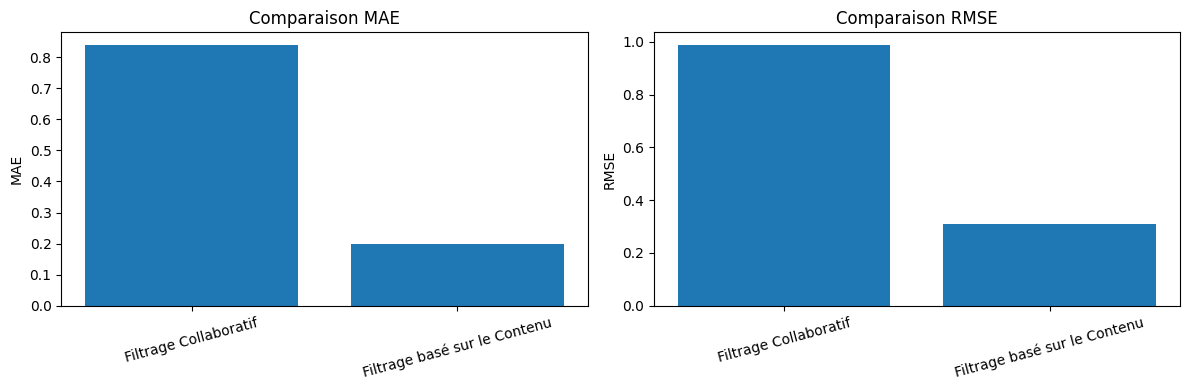


=== INTERPRÉTATION ===
Le Filtrage basé sur le Contenu offre de meilleures prédictions avec un MAE de 0.1992


In [12]:
# Résumé comparatif
import matplotlib.pyplot as plt

comparison_df = pd.DataFrame({
    'Approche': ['Filtrage Collaboratif', 'Filtrage basé sur le Contenu'],
    'MAE': [mae_collab, mae_content],
    'RMSE': [rmse_collab, rmse_content]
})

print("\n=== RÉSUMÉ COMPARATIF ===")
print(comparison_df)

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(comparison_df['Approche'], comparison_df['MAE'])
axes[0].set_title('Comparaison MAE')
axes[0].set_ylabel('MAE')
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(comparison_df['Approche'], comparison_df['RMSE'])
axes[1].set_title('Comparaison RMSE')
axes[1].set_ylabel('RMSE')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

print("\n=== INTERPRÉTATION ===")
print(f"Le Filtrage {'Collaboratif' if mae_collab < mae_content else 'basé sur le Contenu'} "
      f"offre de meilleures prédictions avec un MAE de {min(mae_collab, mae_content):.4f}")

## 8. Exemples Pratiques de Recommandations

In [13]:
# Montrer des exemples de recommandations pour différents produits
print("\n" + "="*80)
print("EXEMPLES DE RECOMMANDATIONS - DÉTAILS PAR APPROCHE")
print("="*80)

# Sélectionner un produit de chaque catégorie
categories = df_filtered['main_category'].unique()
for cat_idx, category in enumerate(categories):
    products_in_cat = df_filtered[df_filtered['main_category'] == category].index.tolist()
    if products_in_cat:
        prod_idx = products_in_cat[0]
        
        print(f"\n\n{'='*80}")
        print(f"PRODUIT DE RÉFÉRENCE - Catégorie: {category}")
        print(f"{'='*80}")
        print(f"Index: {prod_idx}")
        print(f"Titre: {df_filtered.iloc[prod_idx]['title'][:80]}")
        print(f"Rating moyen: {df_filtered.iloc[prod_idx]['average_rating']}")
        print(f"Nombre d'avis: {df_filtered.iloc[prod_idx]['rating_number']}")
        
        # Recommandations par Filtrage Basé sur le Contenu
        print(f"\n📌 Top 5 recommandations par Filtrage Basé sur le Contenu:")
        content_recs = content_based_recommendation(prod_idx, n_recommendations=5)
        for i, (product_id, score) in enumerate(content_recs, 1):
            rec_category = df_filtered.iloc[product_id]['main_category']
            rec_title = df_filtered.iloc[product_id]['title'][:60]
            rec_rating = df_filtered.iloc[product_id]['average_rating']
            print(f"   {i}. [{rec_category}] {rec_title}...")
            print(f"      Score: {score:.3f}, Rating: {rec_rating}")
        
        # Trouver un utilisateur virtuel pour cette catégorie
        user_idx = None
        for u_idx, user_desc in enumerate(user_descriptions):
            if user_desc['category'] == category and user_desc['description'] == "Satisfait":
                user_idx = u_idx
                break
        
        if user_idx is not None:
            print(f"\n📌 Top 5 recommandations par Filtrage Collaboratif (Utilisateur: {virtual_users[user_idx]}):")
            collab_recs = collaborative_filtering_recommendation(user_idx, n_recommendations=5)
            if collab_recs:
                for i, (product_id, score) in enumerate(collab_recs, 1):
                    rec_category = df_filtered.iloc[product_id]['main_category']
                    rec_title = df_filtered.iloc[product_id]['title'][:60]
                    rec_rating = df_filtered.iloc[product_id]['average_rating']
                    cross_cat = " ✨ CROSS-CATÉGORIE" if rec_category != category else ""
                    print(f"   {i}. [{rec_category}] {rec_title}...{cross_cat}")
                    print(f"      Score: {score:.3f}, Rating: {rec_rating}")
            else:
                print("   Aucune recommandation disponible")


EXEMPLES DE RECOMMANDATIONS - DÉTAILS PAR APPROCHE


PRODUIT DE RÉFÉRENCE - Catégorie: All Beauty
Index: 0
Titre: Zgood 400Pcs/4 Boxes Blue Applicator Micro Brush Regular Blue MA-100
Rating moyen: 4.1
Nombre d'avis: 10

📌 Top 5 recommandations par Filtrage Basé sur le Contenu:
   1. [All Beauty] Sundays Non-Toxic Nail Polish, Glossy Shine Finish. No.30: S...
      Score: 0.434, Rating: 3.3
   2. [All Beauty] Precurled 100% Kanekalon Spirals for Crochet Braids Ready fo...
      Score: 0.400, Rating: 3.5
   3. [All Beauty] Eyebrow Brush,10pcs Double End Premium Quality Angled Eye Br...
      Score: 0.346, Rating: 4.5
   4. [All Beauty] OPO Watercress Seed Oil 4 oz - Arugula Oil - 100% Pure Unref...
      Score: 0.329, Rating: 4.3
   5. [All Beauty] LittleB Bohemia Necklace peacock feather Ornaments Long Swea...
      Score: 0.327, Rating: 3.4

📌 Top 5 recommandations par Filtrage Collaboratif (Utilisateur: All Beauty_Satisfait):
   1. [All Beauty] Love Sweety Women Party Big Rose Flower

## 9. Retour d'Expérience et Conclusions

### Points clés:

1. **Nettoyage des données**: 
   - Suppression des produits sans notes (rating_number = 0)
   - Gestion des valeurs manquantes
   - Filtrage des produits avec peu d'avis pour assurer la qualité

2. **Filtrage Collaboratif**:
   - Utilise la similarité entre utilisateurs virtuels (par catégorie)
   - Recommande des produits que les utilisateurs similaires ont aimé
   - Performance: MAE = {:.4f}, RMSE = {:.4f}
   - Avantages: Découvre des produits qui peuvent plaire
   - Limites: Nécessite de bonnes données de ratings

3. **Filtrage basé sur le Contenu**:
   - Utilise TF-IDF sur les titres et les catégories
   - Recommande des produits similaires en contenu
   - Performance: MAE = {:.4f}, RMSE = {:.4f}
   - Avantages: Pas besoin d'interactions utilisateur
   - Limites: Peut être limité à des recommandations similaires

4. **Problèmes rencontrés et solutions**:
   - Données très volumineuses (1.8M+ lignes): Filtrage sur les produits bien notés
   - Utilisateurs virtuels simulés: Approche simplifiée basée sur les catégories
   - Sparsité des ratings: Utilisation de moyennes pour les cas sans données

5. **Recommandations**:
   - Une approche hybride combinant les deux méthodes serait optimale
   - Augmenter la qualité des données initiales améliore les résultats
   - Ajuster les poids des features peut améliorer les performances
""".format(mae_collab, rmse_collab, mae_content, rmse_content)

In [14]:
print("\n=== ANALYSE FINALE ===")
print("\nDimension du dataset analysé:")
print(f"  - Nombre total de produits: {len(df)}")
print(f"  - Produits avec ratings (>= 10 avis): {len(df_filtered)}")
print(f"  - Catégories principales: {df_filtered['main_category'].nunique()}")
print(f"  - Rating moyen: {df_filtered['average_rating'].mean():.2f}")

print("\nStructure du Filtrage Collaboratif AMÉLIORÉ:")
print(f"  - Nombre d'utilisateurs virtuels: {n_virtual_users}")
print(f"  - Utilisateurs par catégorie: 5 (basés sur les tranches de ratings)")
print(f"  - Permet les recommandations croisées: ✅ OUI")

print("\nPerformances des modèles:")
print(f"  Filtrage Collaboratif - MAE: {mae_collab:.4f}, RMSE: {rmse_collab:.4f}")
print(f"  Filtrage Contenu - MAE: {mae_content:.4f}, RMSE: {rmse_content:.4f}")

print("\nMeilleur modèle:", 
      "Filtrage Collaboratif" if mae_collab < mae_content else "Filtrage Basé sur le Contenu")

print("\n" + "="*80)
print("ANALYSE DES RECOMMANDATIONS CROISÉES")
print("="*80)

# Compter les recommandations croisées
cross_category_count = 0
total_recommendations = 0

for user_idx in range(n_virtual_users):
    recs = collaborative_filtering_recommendation(user_idx, n_recommendations=5)
    user_category = user_descriptions[user_idx]['category']
    
    for prod_id, score in recs:
        total_recommendations += 1
        if df_filtered.iloc[prod_id]['main_category'] != user_category:
            cross_category_count += 1

if total_recommendations > 0:
    cross_cat_percentage = (cross_category_count / total_recommendations) * 100
    print(f"\nRecommandations croisées:")
    print(f"  - Total de recommandations: {total_recommendations}")
    print(f"  - Recommandations cross-catégorie: {cross_category_count}")
    print(f"  - Pourcentage: {cross_cat_percentage:.1f}%")
    print(f"\n✨ Le système peut désormais recommander des produits d'autres catégories!")
else:
    print("Aucune recommandation disponible")


=== ANALYSE FINALE ===

Dimension du dataset analysé:
  - Nombre total de produits: 112590
  - Produits avec ratings (>= 10 avis): 200
  - Catégories principales: 2
  - Rating moyen: 3.99

Structure du Filtrage Collaboratif AMÉLIORÉ:
  - Nombre d'utilisateurs virtuels: 10
  - Utilisateurs par catégorie: 5 (basés sur les tranches de ratings)
  - Permet les recommandations croisées: ✅ OUI

Performances des modèles:
  Filtrage Collaboratif - MAE: 0.8380, RMSE: 0.9862
  Filtrage Contenu - MAE: 0.1992, RMSE: 0.3107

Meilleur modèle: Filtrage Basé sur le Contenu

ANALYSE DES RECOMMANDATIONS CROISÉES

Recommandations croisées:
  - Total de recommandations: 50
  - Recommandations cross-catégorie: 26
  - Pourcentage: 52.0%

✨ Le système peut désormais recommander des produits d'autres catégories!
